<a href="https://colab.research.google.com/github/devmurarijay13/pytorch-deep-learning/blob/main/cnn-fashion-mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install torchinfo

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
from torchinfo import summary
from torch.utils.data import Dataset,DataLoader
from torchvision import datasets, transforms, models
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import numpy as np
import time
import copy
from PIL import Image
from torchvision.utils import make_grid
import os

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'using device : {device}')

using device : cuda


In [5]:
torch.manual_seed(42)

In [6]:
df = pd.read_csv('/content/fashion-mnist_train.csv')

In [7]:
df.sample(5)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
22233,6,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
44654,0,0,0,0,0,0,0,0,0,28,...,153,131,19,0,0,1,0,0,0,0
45220,4,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0
28879,3,0,0,0,0,0,0,0,0,9,...,17,0,0,1,0,0,0,0,0,0
22021,0,0,0,0,0,0,0,0,0,32,...,39,131,93,17,0,0,0,0,0,0


In [8]:
df.shape

(60000, 785)

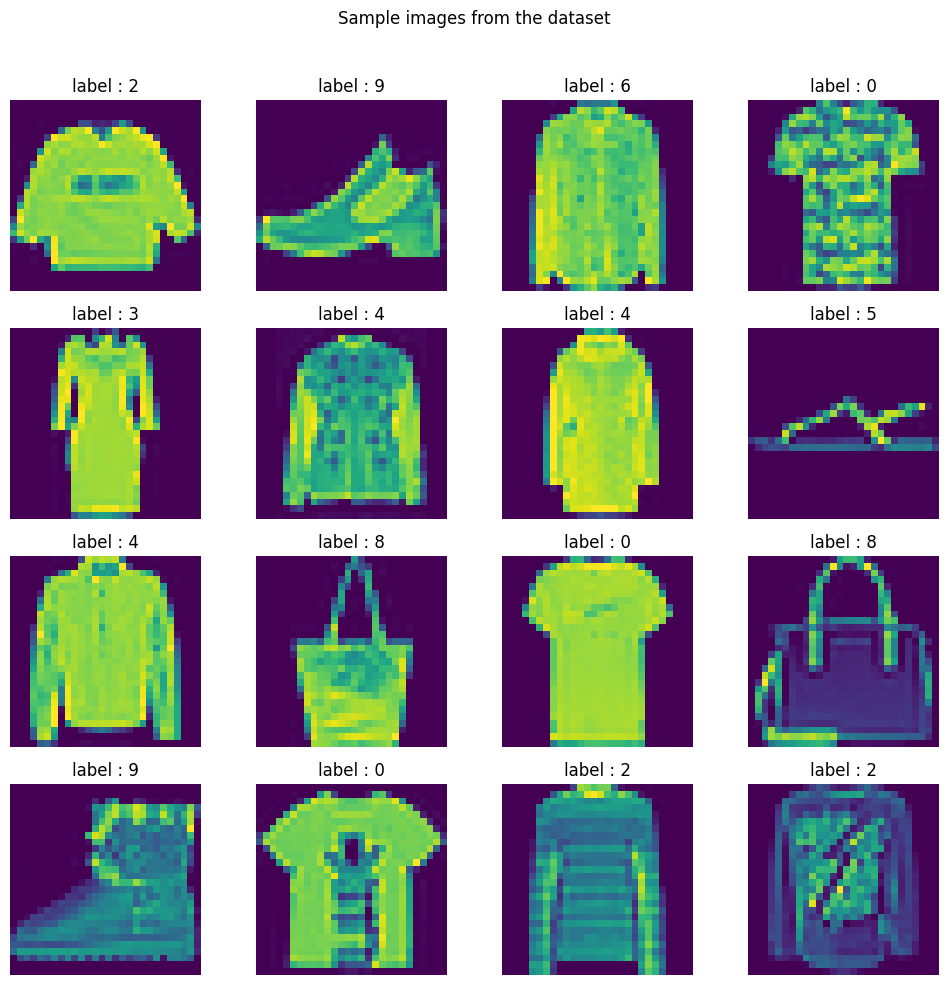

In [9]:
fig, axes = plt.subplots(4,4,figsize=(10,10))
fig.suptitle('Sample images from the dataset')

for i, ax in enumerate(axes.flat):
    image = df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(image)
    ax.axis('off')
    ax.set_title(f"label : {df.iloc[i,0]}")

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [10]:
X = df.drop(columns=['label'])
y = df['label']

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
X_train = X_train/255.0
X_test = X_test/255.0

In [13]:
class CustomDataset(Dataset):

    def __init__(self,features,labels):
        self.features = torch.tensor(features.values,dtype=torch.float32).reshape(-1,1,28,28)
        self.labels = torch.tensor(labels.values,dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self,idx):
        return self.features[idx],self.labels[idx]

100%|██████████| 26.4M/26.4M [00:00<00:00, 116MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.56MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 60.8MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.6MB/s]


Training samples: 60000
Test samples: 10000
Training batches: 938
Test batches: 157


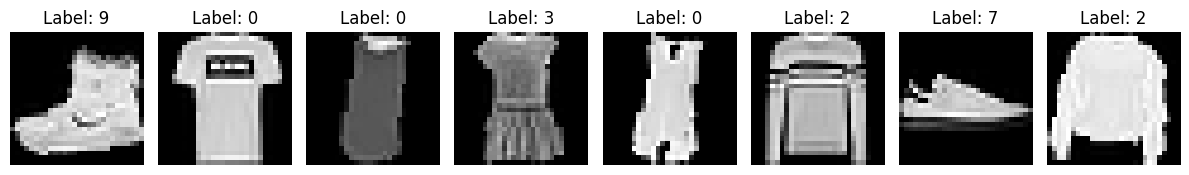

In [36]:
# Define transforms for training and testing
train_transform = transforms.Compose([
    transforms.RandomRotation(10),                    # Random rotation ±10 degrees
    transforms.RandomHorizontalFlip(p=0.5),          # Random horizontal flip
    transforms.ToTensor(),                            # Convert to tensor
    transforms.Normalize((0.1307,), (0.3081,))       # MNIST normalization
])

test_transform = transforms.Compose([
    transforms.ToTensor(),                            # Convert to tensor
    transforms.Normalize((0.1307,), (0.3081,))       # MNIST normalization
])

# Load MNIST dataset
train_dataset = datasets.FashionMNIST('./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.FashionMNIST('./data', train=False, transform=test_transform)

# Create data loaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

# Visualize some samples
def visualize_samples(dataset, num_samples=8):
    plt.figure(figsize=(12, 3))
    for i in range(num_samples):
        image, label = dataset[i]
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.title(f'Label: {label}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

visualize_samples(train_dataset)

In [44]:
learning_rate = 0.001
epochs = 50

In [45]:
class NeuralNetwork(nn.Module):

    def __init__(self, input_features):

        super().__init__()
        self.input_dims = input_features

        self.feature_extractor = nn.Sequential(

            nn.Conv2d(input_features,128,kernel_size=3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2),

            nn.Conv2d(128,64,kernel_size=3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2),

            nn.Conv2d(64,32,kernel_size=3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )

        self._to_linear = None
        self._get_conv_output()

        self.classifier = nn.Sequential(

            nn.Flatten(),
            nn.Linear(self._to_linear,128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64,10)
        )

    def _get_conv_output(self):
        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, 28, 28)  # ✅ correct input size
            output = self.feature_extractor(dummy_input)
            self._to_linear = output.view(1, -1).shape[1]  # ✅ get number

    def forward(self,X):
        features = self.feature_extractor(X)
        output = self.classifier(features)
        return output

In [46]:
model = NeuralNetwork(1)

model = model.to(device)

optimizer = optim.Adam(model.parameters(),lr=learning_rate)
criterion = nn.CrossEntropyLoss()

In [47]:
summary(model)

Layer (type:depth-idx)                   Param #
NeuralNetwork                            --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       1,280
│    └─BatchNorm2d: 2-2                  256
│    └─ReLU: 2-3                         --
│    └─MaxPool2d: 2-4                    --
│    └─Conv2d: 2-5                       73,792
│    └─BatchNorm2d: 2-6                  128
│    └─ReLU: 2-7                         --
│    └─MaxPool2d: 2-8                    --
│    └─Conv2d: 2-9                       18,464
│    └─BatchNorm2d: 2-10                 64
│    └─ReLU: 2-11                        --
│    └─MaxPool2d: 2-12                   --
├─Sequential: 1-2                        --
│    └─Flatten: 2-13                     --
│    └─Linear: 2-14                      36,992
│    └─ReLU: 2-15                        --
│    └─BatchNorm1d: 2-16                 256
│    └─Dropout: 2-17                     --
│    └─Linear: 2-18                      8,256
│    └

In [48]:
#### training loop
model.train()
train_losses = []
train_accuracies = []

for epoch in range(epochs):

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_features,batch_labels in train_loader:

        batch_features,batch_labels = batch_features.to(device),batch_labels.to(device)

        optimizer.zero_grad()

        output = model(batch_features) ### forward pass

        loss = criterion(output,batch_labels) ### loss calculation

        loss.backward()

        optimizer.step()### upgrade grads

        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(output.data, 1)
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

        # Print progress
        if (i + 1) % 200 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(train_loader)}], '
            f'Loss: {loss.item():.4f}, Accuracy: {100 * correct / total:.2f}%')

    # Calculate epoch statistics
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f'Epoch [{epoch+1}/{epochs}] completed: '
                f'Average Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%')


Epoch [1/50] completed: Average Loss: 0.5386, Accuracy: 81.03%
Epoch [2/50] completed: Average Loss: 0.3664, Accuracy: 86.96%
Epoch [3/50] completed: Average Loss: 0.3283, Accuracy: 88.13%
Epoch [4/50] completed: Average Loss: 0.3037, Accuracy: 89.17%
Epoch [5/50] completed: Average Loss: 0.2897, Accuracy: 89.72%
Epoch [6/50] completed: Average Loss: 0.2807, Accuracy: 89.91%
Epoch [7/50] completed: Average Loss: 0.2741, Accuracy: 90.18%
Epoch [8/50] completed: Average Loss: 0.2634, Accuracy: 90.58%
Epoch [9/50] completed: Average Loss: 0.2570, Accuracy: 90.84%
Epoch [10/50] completed: Average Loss: 0.2515, Accuracy: 91.00%
Epoch [11/50] completed: Average Loss: 0.2453, Accuracy: 91.23%
Epoch [12/50] completed: Average Loss: 0.2401, Accuracy: 91.47%
Epoch [13/50] completed: Average Loss: 0.2363, Accuracy: 91.61%
Epoch [14/50] completed: Average Loss: 0.2310, Accuracy: 91.72%
Epoch [15/50] completed: Average Loss: 0.2280, Accuracy: 91.76%
Epoch [16/50] completed: Average Loss: 0.2317, Ac

In [49]:
    model.eval()

NeuralNetwork(
  (feature_extractor): Sequential(
    (0): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=288, out_features=128, bias=True)
    (2): ReLU()
  

In [50]:
total = 0
correct = 0

with torch.no_grad():

    for batch_features, batch_labels in test_loader:

        batch_features,batch_labels = batch_features.to(device),batch_labels.to(device)

        outputs = model(batch_features)

        _,predicted = torch.max(outputs,1)

        total += batch_labels.shape[0]

        correct += (predicted == batch_labels).sum().item()


print(correct/total)

0.9249


In [51]:
total = 0
correct = 0

with torch.no_grad():

    for batch_features, batch_labels in train_loader:

        batch_features,batch_labels = batch_features.to(device),batch_labels.to(device)


        outputs = model(batch_features)

        _,predicted = torch.max(outputs,1)

        total += batch_labels.shape[0]

        correct += (predicted == batch_labels).sum().item()


print(correct/total)

0.9432166666666667
